### Overview

This code explores the spectral distances among graphs of a given family.

In [1]:
import sys
import os
from os.path import abspath
sys.path.insert(0, os.path.join(abspath(os.getcwd()), 'modules'))

from graphs import get_graph, compute_matrix_of_pairwise_spectral_distances, plot_average_spectral_distance_for_same_param_val, real_eigval_and_eigvec_for_potentially_nonsymmetric_matrix, compute_zfs_transf_Gramian_spectra_of_given_two_graphs, spectral_distance
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from copy import deepcopy

matrix_types = ['adjacency', 'laplacian', 'signless_laplacian', 'normalized_laplacian', 'distance_normalized_laplacian']
n = 100
n_graphs_per_param_val = 100

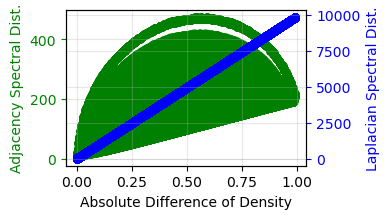

In [117]:
fig, ax = plt.subplots(figsize = (4, 2.3))
ax2 = ax.twinx()

# fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(5, 3))
# ax2 = ax1.twinx()   # twin axis for first subplot
# ax4 = ax3.twinx()   # twin axis for second subplot

n_graphs_per_param_val_for_paper = 10

# p_values_for_paper = np.linspace(0.3, 0.7, 5)   # the plot for the adjacency matrix is more linear in this range
# p_values_for_paper = np.concatenate([np.linspace(0.1, 0.9, 8), np.array([0.99])])
p_values_for_paper = np.arange(0, 1, 0.01)
graphs_ER_for_paper = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_paper for _ in range(n_graphs_per_param_val_for_paper)]
_ = compute_matrix_of_pairwise_spectral_distances(graphs_ER_for_paper, matrix_type='adjacency', plot_type='scatter', axis=ax)

p_values_for_paper = np.arange(0, 1, 0.01)
graphs_ER_for_paper = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_paper for _ in range(n_graphs_per_param_val_for_paper)]
_ = compute_matrix_of_pairwise_spectral_distances(graphs_ER_for_paper, matrix_type='laplacian', plot_type='scatter', axis=ax2, right_axis=True)

plt.savefig('figures/spec-dist-vs-density-diff.png', dpi=300, bbox_inches='tight')
plt.show()

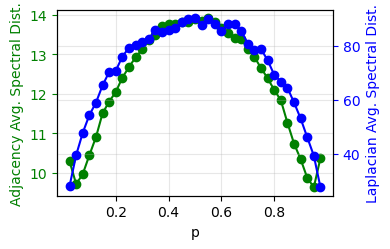

In [2]:
# for the paper

n_graphs_per_param_val_for_paper_2 = 1000

fig, ax = plt.subplots(figsize=(4, 2.6))
ax2 = ax.twinx()

# p_values_for_paper_2 = np.arange(0, 1 + 1e-10, 0.025)
p_values_for_paper_2 = np.arange(0.025, 0.999, 0.025)
# p_values_for_adj_for_paper_2 = np.concatenate([[0.005], p_values_for_paper_2[1:-1], [0.995]])
p_values_for_adj_for_paper_2 = p_values_for_paper_2

graphs_ER_for_adj_for_paper_2 = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_adj_for_paper_2 for _ in range(n_graphs_per_param_val_for_paper_2)]
_ = plot_average_spectral_distance_for_same_param_val(graphs_ER_for_adj_for_paper_2, matrix_type='adjacency', param_name='p',
                                                        param_values=p_values_for_adj_for_paper_2,
                                                        n_graphs_per_param_val=n_graphs_per_param_val_for_paper_2,
                                                        axis=ax)#, plot_violin_and_medians=True)

graphs_ER_for_paper_2 = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_paper_2 for _ in range(n_graphs_per_param_val_for_paper_2)]
_ = plot_average_spectral_distance_for_same_param_val(graphs_ER_for_paper_2, matrix_type='laplacian', param_name='p', param_values=p_values_for_paper_2,
                                                        n_graphs_per_param_val=n_graphs_per_param_val_for_paper_2,
                                                        axis=ax2, right_axis=True),#, plot_violin_and_medians=True)

plt.savefig('figures/avg_spec_dist.pdf', dpi=300, bbox_inches='tight')
plt.show()

Computing spectral distances:   0%|          | 0/39 [00:00<?, ?it/s]c:\Users\usama\OneDrive\Desktop\distinguish-control-graphs\modules\graphs.py:15: RuntimeWarning: divide by zero encountered in log10
  from copy import deepcopy
Computing spectral distances: 100%|██████████| 39/39 [00:25<00:00,  1.52it/s]


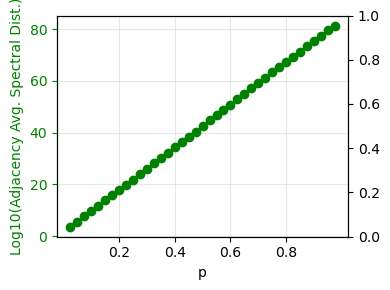

In [31]:
n_graphs_per_param_val_for_paper_3 = 50

fig, ax = plt.subplots(figsize=(4, 3))
ax2 = ax.twinx()

p_values_for_paper_3 = np.arange(0.025, 0.999, 0.025)
# p_values_for_paper_3 = np.arange(0.025, 0.1, 0.025)
p_values_for_adj_for_paper_3 = p_values_for_paper_3

graphs_ER_for_adj_for_paper_3 = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_adj_for_paper_3 for _ in range(n_graphs_per_param_val_for_paper_3)]
_ = plot_average_spectral_distance_for_same_param_val(graphs_ER_for_adj_for_paper_3, matrix_type='adjacency', input='all_ones', param_name='p',
                                                        param_values=p_values_for_adj_for_paper_3,
                                                        n_graphs_per_param_val=n_graphs_per_param_val_for_paper_3,
                                                        axis=ax, log_scale=True)#, plot_violin_and_medians=True)

# graphs_ER_for_paper_3 = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_paper_3 for _ in range(n_graphs_per_param_val_for_paper_3)]
# _ = plot_average_spectral_distance_for_same_param_val(graphs_ER_for_paper_3, matrix_type='neg_laplacian', input='zfs', param_name='p',
#                                                         param_values=p_values_for_paper_3,
#                                                         n_graphs_per_param_val=n_graphs_per_param_val_for_paper_3,
#                                                         axis=ax2, right_axis=True),#, plot_violin_and_medians=True)

# plt.savefig('figures/avg_spec_dist.pdf', dpi=300, bbox_inches='tight')
plt.show()

Computing spectral distances:   0%|          | 0/39 [00:00<?, ?it/s]/data/usama/controllability_and_distinguishability/gramian_spectrum_across_similarity_transformation/distinguish-control-graphs/modules/graphs.py:650: RuntimeWarning: divide by zero encountered in log10
  dist_matrix = np.where(dist_matrix > 1e-10, np.log10(dist_matrix), 0)
Computing spectral distances: 100%|██████████| 39/39 [34:09<00:00, 52.56s/it]


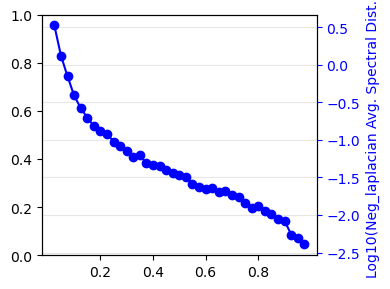

In [12]:
n_graphs_per_param_val_for_paper_3 = 100

fig, ax = plt.subplots(figsize=(4, 3))
ax2 = ax.twinx()

p_values_for_paper_3 = np.arange(0.025, 0.999, 0.025)
# p_values_for_paper_3 = np.arange(0.025, 0.1, 0.025)

graphs_ER_for_paper_3 = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_paper_3 for _ in range(n_graphs_per_param_val_for_paper_3)]
_ = plot_average_spectral_distance_for_same_param_val(graphs_ER_for_paper_3, matrix_type='neg_laplacian', input='zfs', param_name='p',
                                                        param_values=p_values_for_paper_3,
                                                        n_graphs_per_param_val=n_graphs_per_param_val_for_paper_3,
                                                        axis=ax2, log_scale=True, right_axis=True),#, plot_violin_and_medians=True)

# plt.savefig('figures/avg_spec_dist.pdf', dpi=300, bbox_inches='tight')
plt.show()

Computing spectral distances: 100%|██████████| 39/39 [34:35<00:00, 53.22s/it]


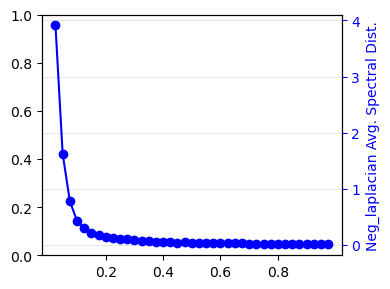

In [13]:
n_graphs_per_param_val_for_paper_3 = 100

fig, ax = plt.subplots(figsize=(4, 3))
ax2 = ax.twinx()

p_values_for_paper_3 = np.arange(0.025, 0.999, 0.025)
# p_values_for_paper_3 = np.arange(0.025, 0.1, 0.025)

graphs_ER_for_paper_3 = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_paper_3 for _ in range(n_graphs_per_param_val_for_paper_3)]
_ = plot_average_spectral_distance_for_same_param_val(graphs_ER_for_paper_3, matrix_type='neg_laplacian', input='zfs', param_name='p',
                                                        param_values=p_values_for_paper_3,
                                                        n_graphs_per_param_val=n_graphs_per_param_val_for_paper_3,
                                                        axis=ax2, right_axis=True),#, plot_violin_and_medians=True)

# plt.savefig('figures/avg_spec_dist.pdf', dpi=300, bbox_inches='tight')
plt.show()

Computing spectra: 100%|██████████| 10/10 [00:09<00:00,  1.05it/s]
c:\Users\usama\OneDrive\Desktop\distinguish-control-graphs\modules\graphs.py:28: RuntimeWarning: divide by zero encountered in log10
  for _ in range(max_attempts):


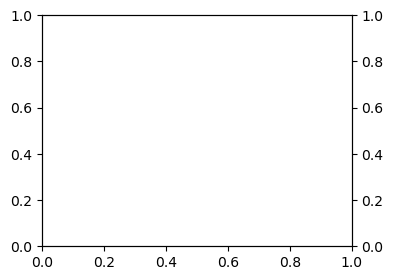

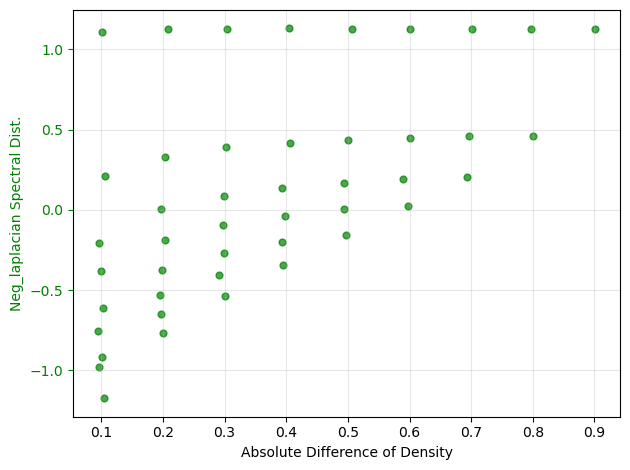

In [10]:
n_graphs_per_param_val_for_paper_3 = 1

fig, ax = plt.subplots(figsize=(4, 3))
ax2 = ax.twinx()

p_values_for_paper_3 = np.arange(0.025, 0.999, 0.1)# 0.025)
# p_values_for_paper_3 = np.arange(0.025, 0.1, 0.025)

graphs_ER_for_paper_3 = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values_for_paper_3 for _ in range(n_graphs_per_param_val_for_paper_3)]
_ = compute_matrix_of_pairwise_spectral_distances(graphs_ER_for_paper_3, dist_scale='log', matrix_type='neg_laplacian', input='zfs', plot_type='scatter')

# plt.savefig('figures/avg_spec_dist.pdf', dpi=300, bbox_inches='tight')
plt.show()

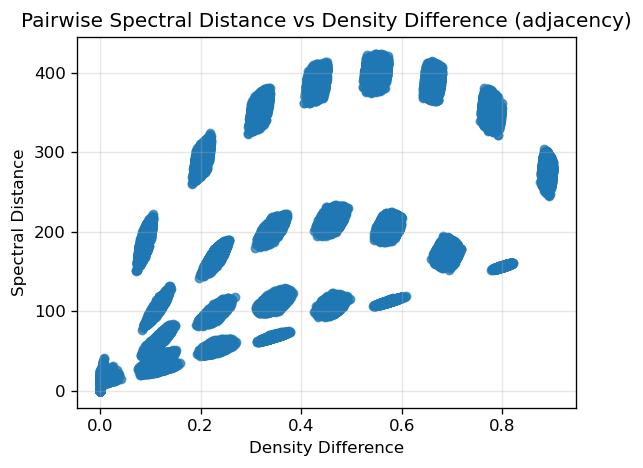

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

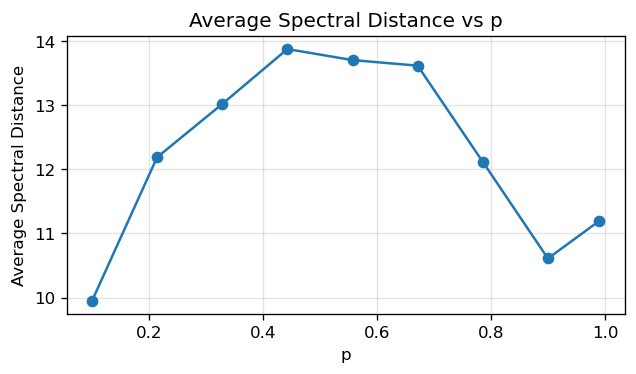

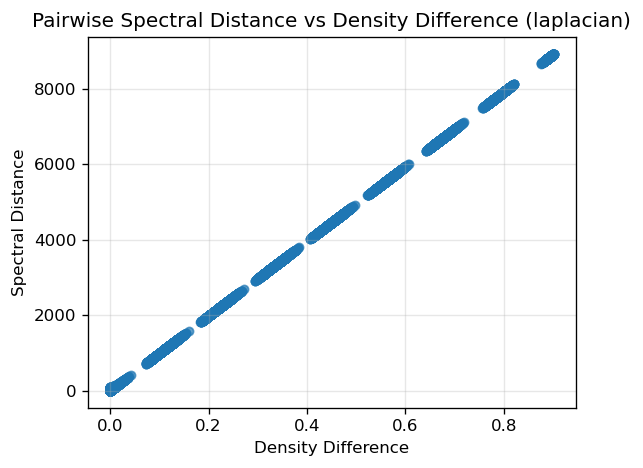

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

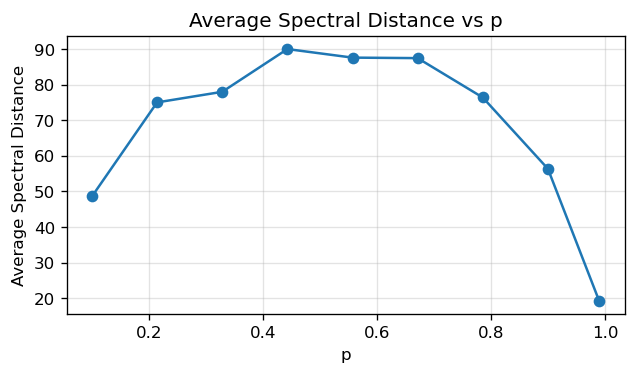

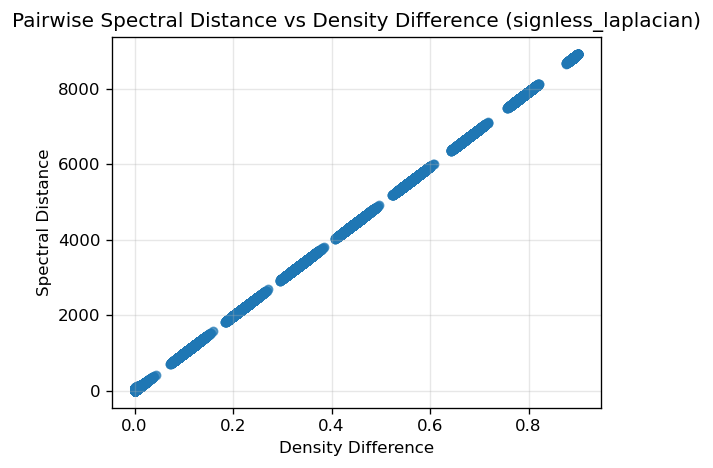

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

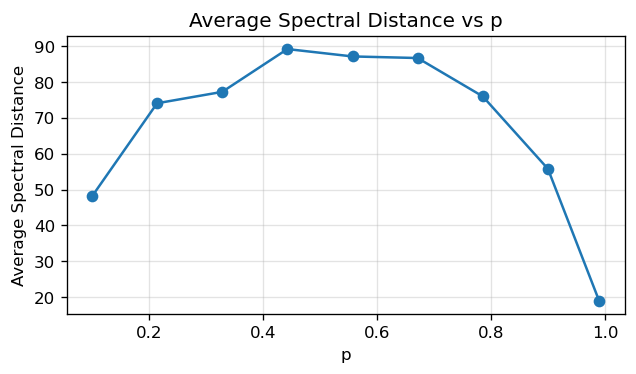

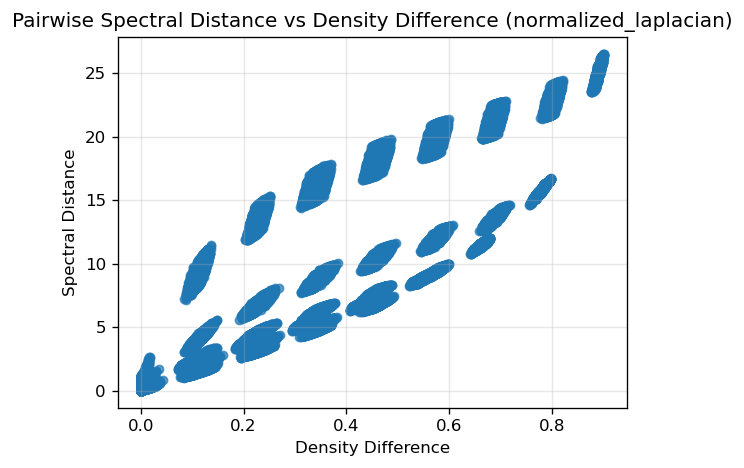

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

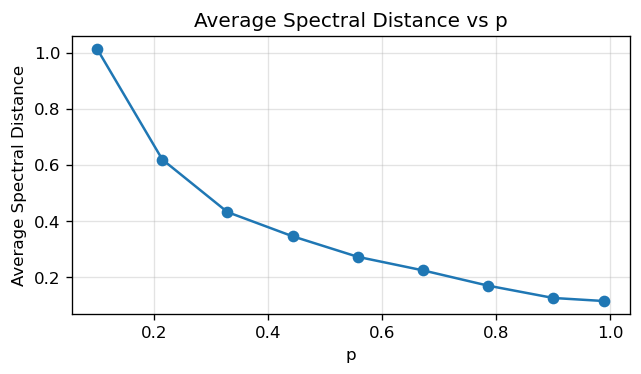

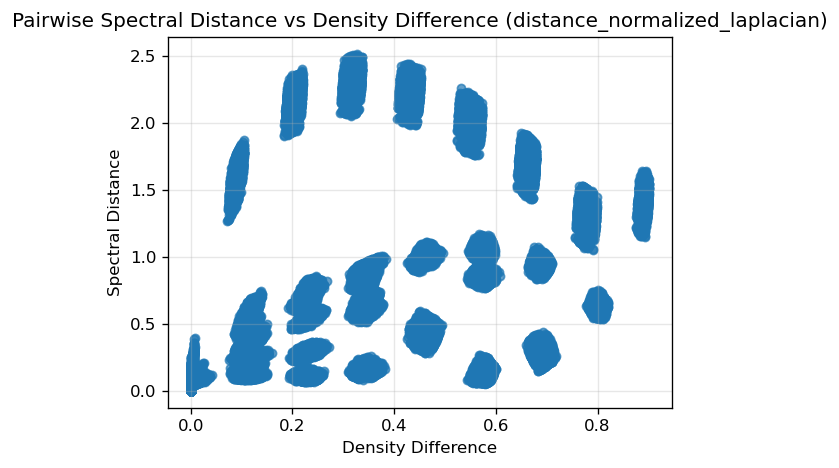

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

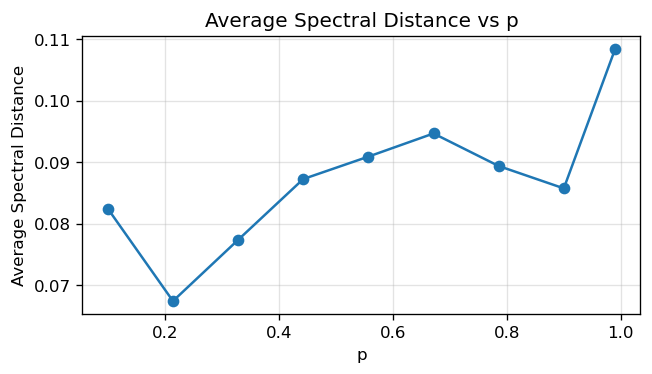

In [47]:
# p_values = np.linspace(0.3, 0.7, 5)   # the plot for the adjacency matrix is more linear in this range
p_values = np.concatenate([np.linspace(0.1, 0.9, 8), np.array([0.99])])
graphs_ER = [get_graph({'type': 'ER', 'n': n, 'p': p}) for p in p_values for _ in range(n_graphs_per_param_val)]
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(graphs_ER, matrix_type=matrix_type, plot_type='scatter')
    _ = plot_average_spectral_distance_for_same_param_val(graphs_ER, matrix_type=matrix_type, param_name='p', param_values=p_values,
                                                          n_graphs_per_param_val=n_graphs_per_param_val)

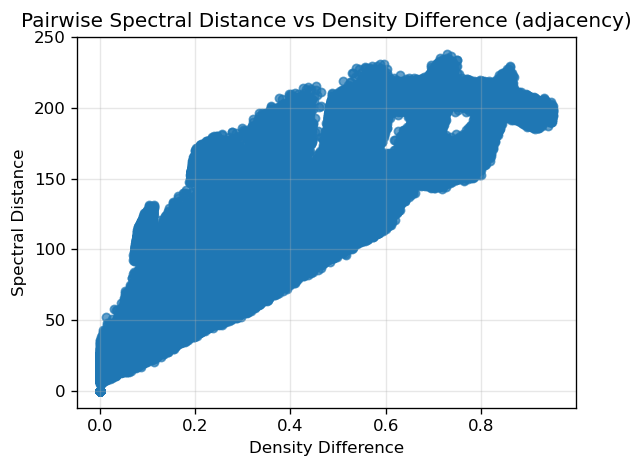

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

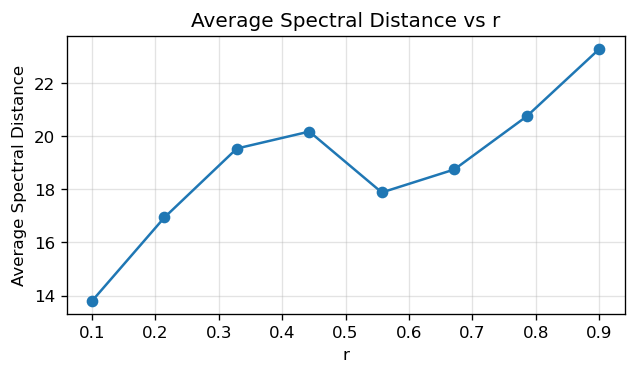

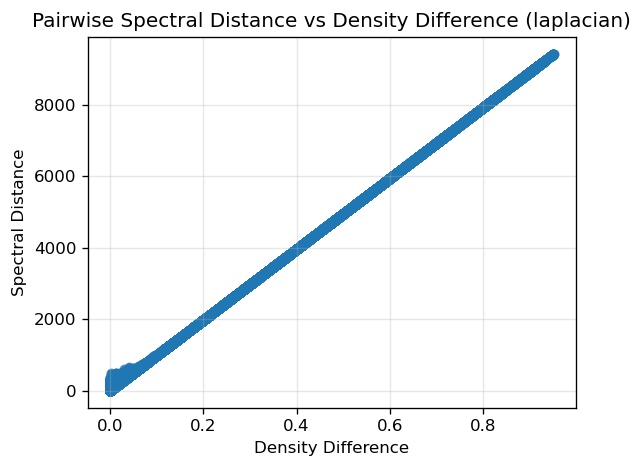

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

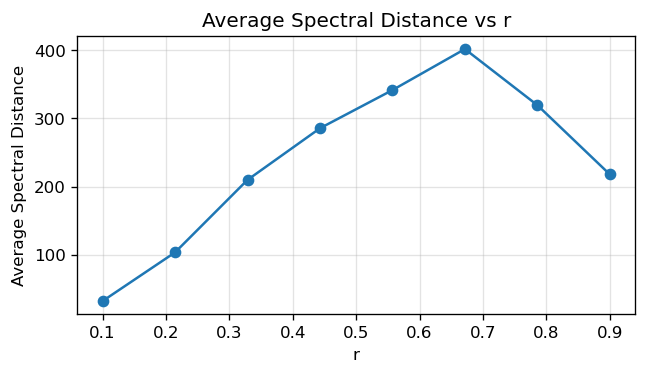

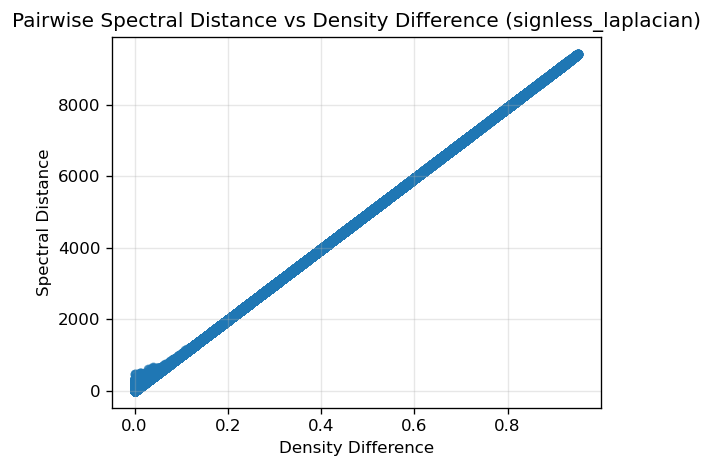

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

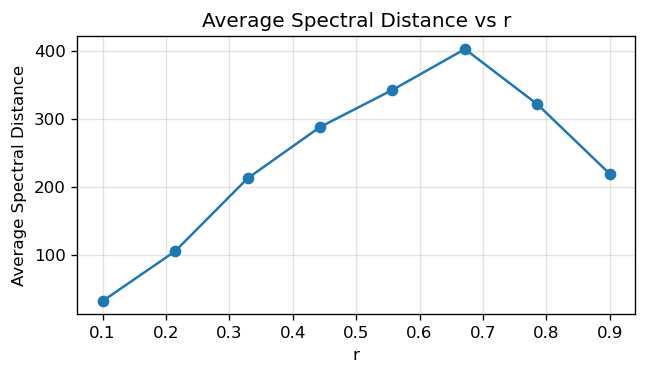

RuntimeError: Matrix is not symmetric. Norm of differnce: nan. Max val: nan

In [49]:
# r_values = np.linspace(0.25, 0.75, 6)     # the plot for adjacency matrix is more linear for this range
r_values = np.linspace(0.1, 0.9, 8)
graphs_RG = [get_graph({'type': 'RG', 'n': n, 'r': r}) for r in r_values for _ in range(n_graphs_per_param_val)]
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(graphs_RG, matrix_type=matrix_type, plot_type='scatter')
    _ = plot_average_spectral_distance_for_same_param_val(graphs_RG, matrix_type=matrix_type, param_name='r', param_values=r_values,
                                                          n_graphs_per_param_val=n_graphs_per_param_val)

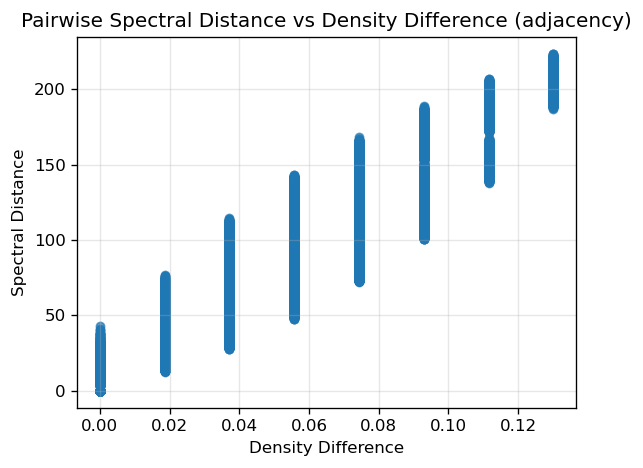

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

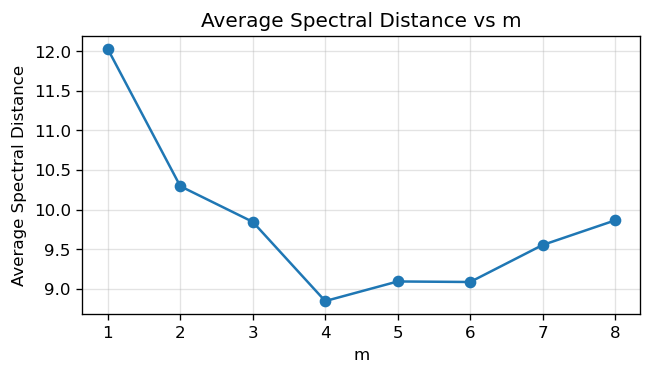

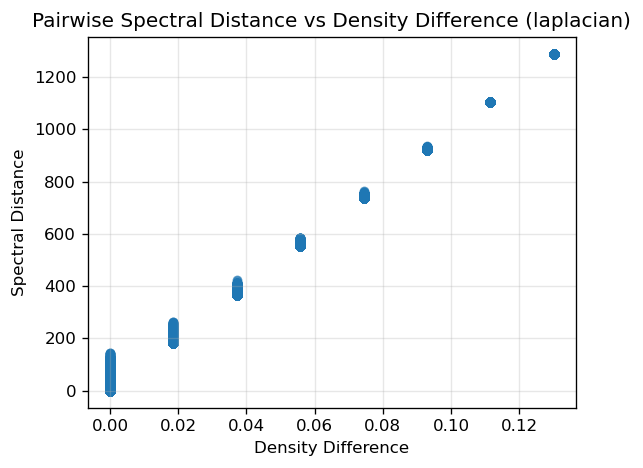

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

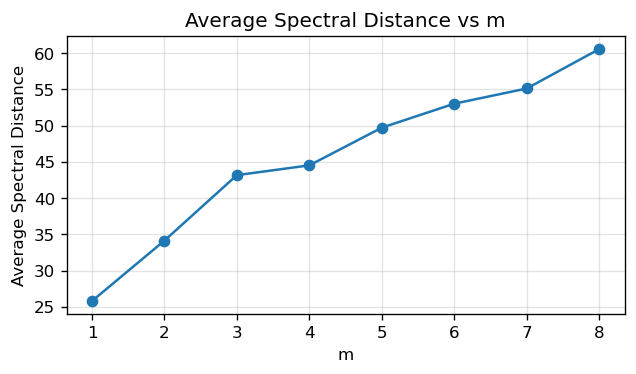

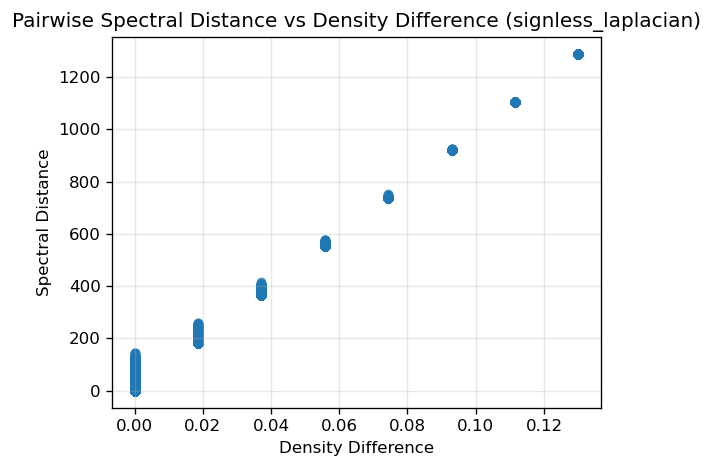

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

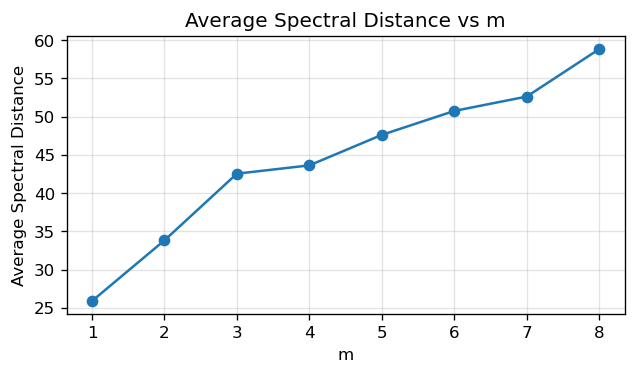

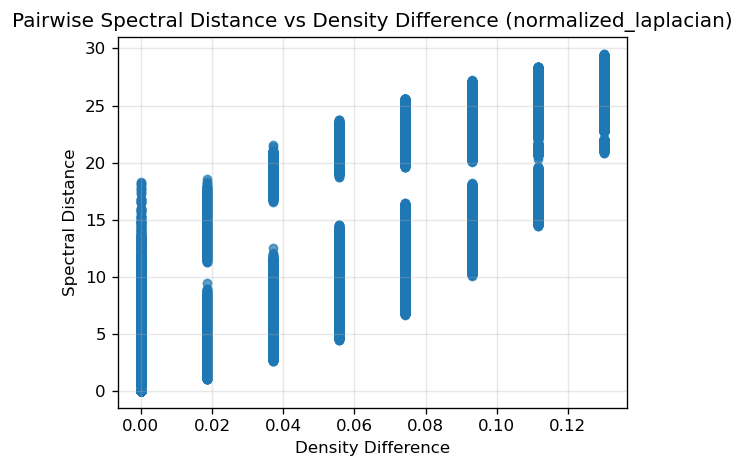

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

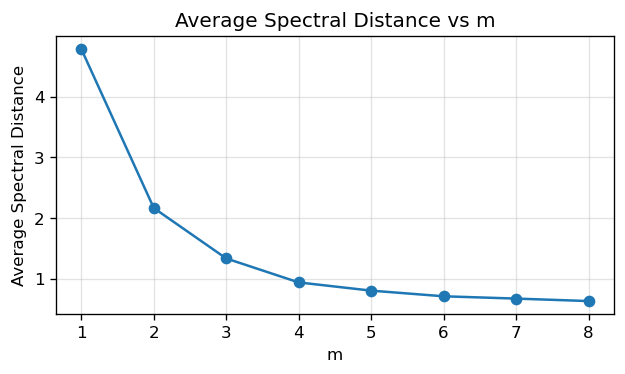

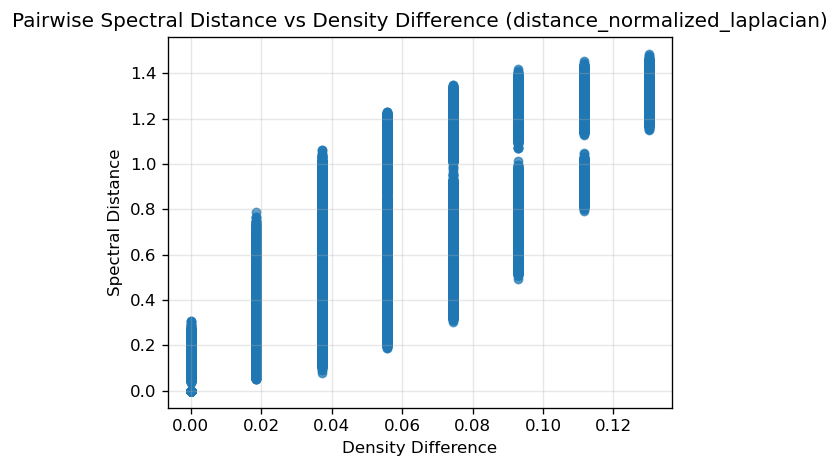

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

<Figure size 600x480 with 0 Axes>

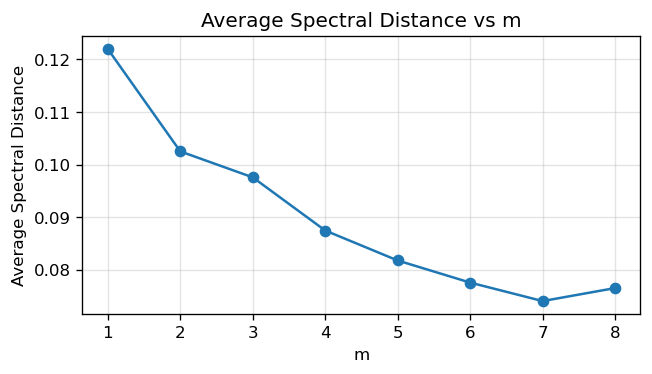

In [52]:
m_values = np.linspace(1, 8, 8)
graphs_BA = [get_graph({'type': 'BA', 'n': n, 'm': m, 'init': {'type': 'complete', 'n': 8}}) for m in m_values for _ in range(n_graphs_per_param_val)]
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(graphs_BA, matrix_type=matrix_type, plot_type='scatter')
    _ = plot_average_spectral_distance_for_same_param_val(graphs_BA, matrix_type=matrix_type, param_name='m', param_values=m_values,
                                                          n_graphs_per_param_val=n_graphs_per_param_val)

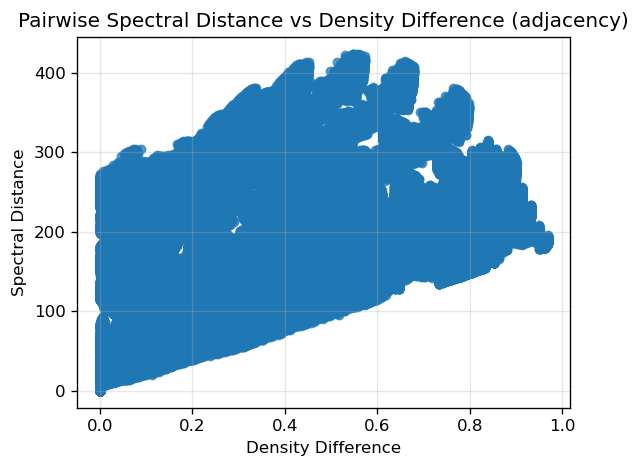

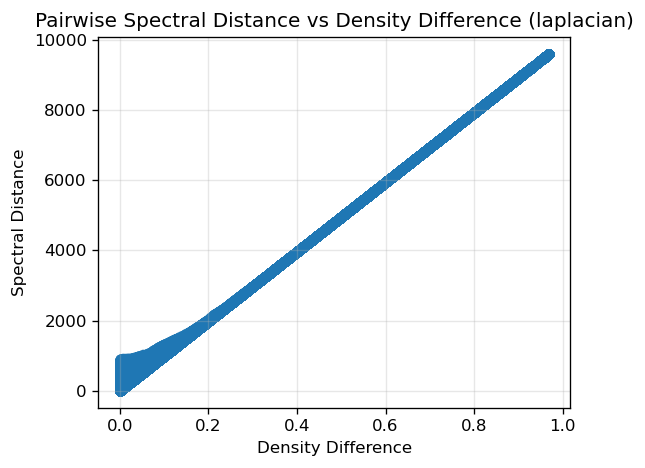

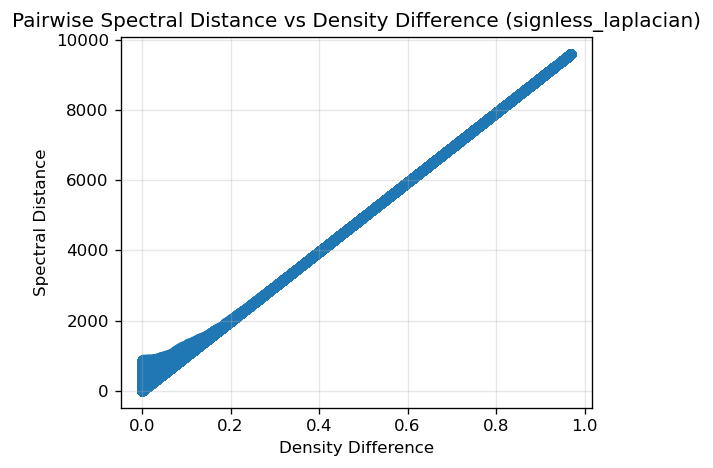

RuntimeError: Matrix is not symmetric. Norm of differnce: nan. Max val: nan

In [53]:
all_graphs = graphs_ER + graphs_RG + graphs_BA
for matrix_type in matrix_types:
    _ = compute_matrix_of_pairwise_spectral_distances(all_graphs, matrix_type=matrix_type, plot_type='scatter')

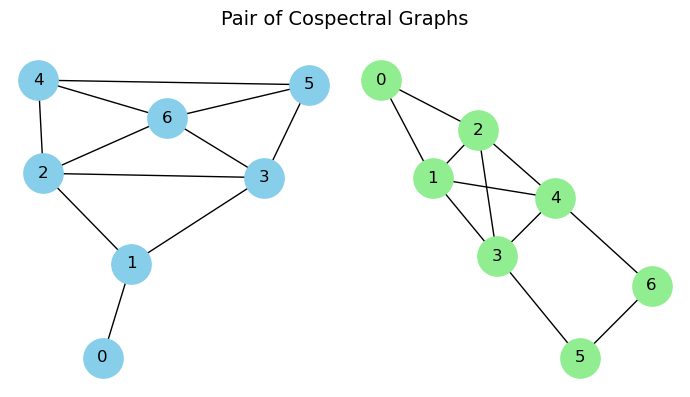

Spec1: [-2.     -1.7785 -1.      0.      0.      1.2892  3.4893]
Spec2: [-2.     -1.7785 -1.     -0.      0.      1.2892  3.4893]
Are they isomorphic? False
Are they cospectral? True

W1 eigenvalues: [1.90000e-03 1.05000e-02 8.38000e-02 2.57300e-01 7.07400e-01 2.03170e+00
 5.42252e+01]
W2 eigenvalues: [1.90000e-03 1.05000e-02 8.38000e-02 2.57300e-01 7.07400e-01 2.03170e+00
 5.42252e+01]
Are the Gramians cospectral? True
[(0, 1), (1, 2), (1, 3), (2, 3), (2, 4), (2, 6), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
[(1, 2), (1, 3), (2, 3), (2, 4), (2, 6), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
[(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 2), (1, 3), (2, 3), (2, 4), (2, 6), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6)]
diff_mat_1_3_eigvals: [-2.44948974  0.          0.          0.          0.          0.
  2.44948974]
spec_dist(adj1, adj3): 2.0961107774905052
bound: 4.898979485566356
[(0, 1), (0, 2), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4), (3, 5), (4, 6), (5, 6)]
[(0, 1), (0, 2), (1, 2), (1,

In [66]:
# Adjacency matrix for Graph 1
adj1 = np.array([
    [0,1,0,0,0,0,0],
    [1,0,1,1,0,0,0],
    [0,1,0,1,1,0,1],
    [0,1,1,0,0,1,1],
    [0,0,1,0,0,1,1],
    [0,0,0,1,1,0,1],
    [0,0,1,1,1,1,0]
])

# Adjacency matrix for Graph 2
adj2 = np.array([
    [0,1,1,0,0,0,0],
    [1,0,1,1,1,0,0],
    [1,1,0,1,1,0,0],
    [0,1,1,0,1,1,0],
    [0,1,1,1,0,0,1],
    [0,0,0,1,0,0,1],
    [0,0,0,0,1,1,0]
])

W1_eigvals, W2_eigvals, A1_eigvals, A2_eigvals, G1, G2 = compute_zfs_transf_Gramian_spectra_of_given_two_graphs(adj1=adj1, adj2=adj2, matrix='adjacency')
# W1_eigvals, W2_eigvals, L1_eigvals, L2_eigvals = compute_zfs_transf_Gramian_spectra_of_given_two_graphs(adj1=adj1, adj2=adj2, matrix='laplacian')


G3 = deepcopy(G1)
print(G3.edges())
G3.remove_edge(0,1)
print(G3.edges())
for node in list(G3.nodes())[2:]:
    G3.add_edge(0, node)
print(G3.edges())

adj3 = nx.to_numpy_array(G3)
diff_mat_1_3 = adj1 - adj3
diff_mat_1_3_eigvals, _ = real_eigval_and_eigvec_for_potentially_nonsymmetric_matrix(diff_mat_1_3)
print(f"diff_mat_1_3_eigvals: {diff_mat_1_3_eigvals}")

print(f"spec_dist(adj1, adj3): {spectral_distance(adj1, adj3)}")
print(f"bound: {2*np.sqrt(6)}")


G4 = deepcopy(G2)
print(G4.edges())
G4.remove_edges_from([(2,3), (2,4), (3,4)])#, (3,4)
print(G4.edges())

adj4 = nx.to_numpy_array(G4)
diff_mat_2_4 = adj2 - adj4
diff_mat_2_4_eigvals, _ = real_eigval_and_eigvec_for_potentially_nonsymmetric_matrix(diff_mat_2_4)
print(f"diff_mat_2_4_eigvals: {diff_mat_2_4_eigvals}")

print(f"spec_dist(adj2, adj4): {spectral_distance(adj2, adj4)}")
print(f"bound: {3*2}")

Max adjacency spectral distance: 4985.754337650509


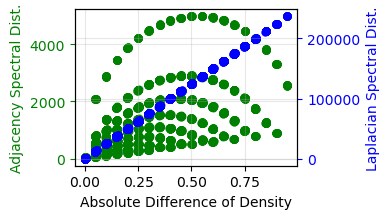

In [2]:
# test block

n_test = 500
n_graphs_per_param_val_for_paper = 5

fig, ax = plt.subplots(figsize = (4, 2.3))
ax2 = ax.twinx()


p_values_for_paper = np.arange(0, 1, 0.05)
graphs_ER_for_paper_test = [get_graph({'type': 'ER', 'n': n_test, 'p': p}) for p in p_values_for_paper for _ in range(n_graphs_per_param_val_for_paper)]
_, _, spec_dist_list_adj = compute_matrix_of_pairwise_spectral_distances(graphs_ER_for_paper_test, matrix_type='adjacency', plot_type='scatter', axis=ax)
print(f"Max adjacency spectral distance: {np.max(spec_dist_list_adj)}")
_ = compute_matrix_of_pairwise_spectral_distances(graphs_ER_for_paper_test, matrix_type='laplacian', plot_type='scatter', axis=ax2, right_axis=True)

plt.show()